In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns


In [3]:
df = pd.read_csv(r"C:\Users\solan\MoodTune\data\procesando\df_80-200_p5_spoty.csv")

In [4]:
# ver todo el output de cada celda
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [5]:
# contar valores unicos por columnas
print(df.nunique())

song_name                             28316
artist_name                            6947
recording_id                          30980
danceable                               988
not_danceable                           988
male                                    989
female                                  989
timbre_bright                           988
timbre_dark                             988
tonal                                   989
atonal                                  989
instrumental                            989
voice                                   989
dortmund_alternative                    528
dortmund_blues                          545
dortmund_electronic                    1000
dortmund_folkcountry                    761
dortmund_funksoulrnb                     85
dortmund_jazz                           328
dortmund_pop                            150
dortmund_raphiphop                      188
dortmund_rock                           801
electronic_ambient              

In [6]:
df.isnull().sum()

song_name                                 0
artist_name                               0
recording_id                              0
danceable                                 0
not_danceable                             0
male                                      0
female                                    0
timbre_bright                             0
timbre_dark                               0
tonal                                     0
atonal                                    0
instrumental                              0
voice                                     0
dortmund_alternative                      0
dortmund_blues                            0
dortmund_electronic                       0
dortmund_folkcountry                      0
dortmund_funksoulrnb                      0
dortmund_jazz                             0
dortmund_pop                              0
dortmund_raphiphop                        0
dortmund_rock                             0
electronic_ambient              

In [7]:
df = df.dropna(subset=['spotify_url'])
# guardar el archivo
df.to_csv(r"C:\Users\solan\MoodTune\data\procesando\df_80-200_p5_spoty.csv", index=False)

In [129]:
print(df.shape)

(21837, 84)


In [121]:
df[['artist_name', 'song_name', 'spotify_url','language', 'lyrics']].sample(10)

,artist_name,song_name,spotify_url,language,lyrics
565,Adriano Celentano,Rifugio bianco,NaN,it,"Pena passà la valle, la-oh E dopo on fià de bosco, la-oh Se slarga i prà nel cielo La-oh, la-oh Varda quanti fiori la-oh Ecco lassù 'na casa, la-oh En grande fiore bianco, la-oh Sbocià de primavera La-oh, la-oh Profumà d'amore la-oh"
12024,Ekatarina Velika,Pored mene,https://open.spotify.com/track/5ZWSqR2kbOD5n4e2Atwljc,hr,"U sumrak otezaju senke I plaze nam po licima Sjaj u ocima je dubok i nestvaran Putujemo recima i razmisljamo koracima Ti i ja, ti i ja U sumrak tvoje hladne ruke Me miluju po grudima Zaboravljam, zaboravljam Da samo ti znas koliko mnogo ih ima Samo ti znas koliko mnogo Pored mene, budi pored mene Pored mene, budi pored mene U sumrak znam da znas da znam Sve o nevaznim stvarima Iza brda je polje, iza polja je suma Iza sume je kuca, iza kuce je put Koji vodi (koji vodi) Koji vodi (koji vodi) Koji vodi do tebe, koji vodi do tebe Jer samo ti znas ... U sumrak tvoje hladne ruke Me miluju po grudima Zaboravljaaaaaaaaam Pored mene ..."
24460,Superheist,Two Faced Check Your Head Up,https://open.spotify.com/track/6CqTLWmFDRPqcgWDxprO3h,en,You led battle field at the bottom where the scum lies Take a good look at your face with your pathetic eyes Reachout to hit the men through to where the motor lies Pulling that sound on the speaker without a brain Check your head up check check your head up Check your head up check check your head up Check your head up check check your head up Check your head up check check your head up Here comes the rain Wash it away Here comes the rain Here comes the rain Wash it away Here comes the rain You led battle field at the bottom where the scum lies Take a good look at your face with your pathetic eyes Reachout to hit the men through to where the motor lies Pulling that sound on the speaker without a brain Check your head up check check your head up Check your head up check check your head up Check your head up check check your head up Check your head up check check your head up Here comes the rain Wash it away Here comes the rain Here comes the rain Wash it away Here comes the rain Here comes the rain Wash it away Here comes the rain Check your head up check check your head up Check your head up check check your head up Check your head up check check your head up Check your head up check check your head up Check your head up check check your head up
1297,Rosenstolz,Geld,https://open.spotify.com/track/1cV2pnyhFB1FkklC9HyoC1,de,"Ich brauch kein Haus, ich möchte drei davon Ich brauch keinen Sekt, ich will Champagner Ich brauch nicht Rügen, ich will Sylt Brauch keinen Pool, ich will das Meer Ich will kein Brot, ich will den Kuchen ganz Ich will kein Wasser, ich will Wein Brauch keine Villa, will das Schloss Und keine Arbeit, nur den Boss Geld, gib mir mehr davon Geld, alles hab ich schon Geld, macht mich wirklich frei Drum schenk mir keine Liebe schenk mir Geld, denn das macht mich schön Geld, willst du mich verwöhnen? Geld, macht mich wirklich schwach Drum schenk mir keine Blumen schenk mir Geld Ich will nicht viel, ich will noch mehr davon Will nicht die Erde, will das All Will keinen Soldat, ich will das Heer Und will am Ende noch viel mehr Will keinen Tanz, ich will das Fest für mich Ich will kein Zögern, will die Tat Ich will das Beste und den Rest für dich Ich hab die Antwort schon parat Geld macht süchtig Geld macht high Bestimmt den König Geld macht frei"
26809,Rebecca Lynn Howard,When My Dreams Come True,NaN,en,"Well I'm no different than the average girl My dreams wrap around the world And I'll be living somewhere in France When my dreams come true There'll be a big boat waitin' on me I'll ride it out to sea And Ill get up on the roof and dance When my dreams come true I'll find the perfect guy Whose heart beats just like mine And his great ambition will be me When my dreams come true He'll say, ""Honey,you sure look nice tonight"" Every night And he'll beat all you've ever seen When 

In [107]:
#crear un df eliminando las filas en las que no spotify_url no tiene información
df = df.dropna(subset=['spotify_url'])


In [108]:
df.head()

,song_name,artist_name,recording_id,danceable,not_danceable,male,female,timbre_bright,timbre_dark,tonal,atonal,instrumental,voice,dortmund_alternative,dortmund_blues,dortmund_electronic,dortmund_folkcountry,dortmund_funksoulrnb,dortmund_jazz,dortmund_pop,dortmund_raphiphop,dortmund_rock,electronic_ambient,electronic_dnb,electronic_house,electronic_techno,electronic_trance,rosamerica_cla,rosamerica_dan,rosamerica_hip,rosamerica_jaz,rosamerica_pop,rosamerica_rhy,rosamerica_roc,rosamerica_spe,tzanetakis_blu,tzanetakis_cla,tzanetakis_cou,tzanetakis_dis,tzanetakis_hip,tzanetakis_jaz,tzanetakis_met,tzanetakis_pop,tzanetakis_reg,tzanetakis_roc,ismir04_rhythm_ChaChaCha,ismir04_rhythm_Jive,ismir04_rhythm_Quickstep,ismir04_rhythm_Rumba-American,ismir04_rhythm_Rumba-International,ismir04_rhythm_Rumba-Misc,ismir04_rhythm_Samba,ismir04_rhythm_Tango,ismir04_rhythm_VienneseWaltz,ismir04_rhythm_Waltz,mood_acoustic,mood_not_acoustic,mood_aggressive,mood_not_aggressive,mood_electronic,mood_not_electronic,mood_happy,mood_not_happy,mood_party,mood_not_party,mood_relaxed,mood_not_relaxed,mood_sad,mood_not_sad,mood_mirex1,mood_mirex2,mood_mirex3,mood_mirex4,mood_mirex5,spotify_url,album_name,album_release_date,duration_ms,popularity,language,playlist_ids,playlists_names,combined_genres,lyrics,genres,tags
0,Motherfucker,Dwarves,2c3486cc-e933-4f05-8dad-442eb3b47d30,0.037,0.963,0.338,0.662,0.913,0.087,0.340,0.660,1.000,0.000,0.127,0.077,0.010,0.050,0.006,0.006,0.026,0.001,0.696,0.482,0.233,0.060,0.020,0.205,0.007,0.001,0.001,0.001,0.003,0.001,0.986,0.001,0.063,0.035,0.078,0.105,0.157,0.314,0.045,0.063,0.063,0.078,0.060,0.811,0.009,0.005,0.003,0.001,0.029,0.011,0.065,0.006,0.003,0.997,0.997,0.003,0.055,0.945,0.138,0.862,0.522,0.478,0.026,0.974,0.051,0.949,0.285,0.089,0.107,0.069,0.450,https://open.spotify.com/track/00F9LiolJIUlkDNknhaVJM,"Blood, Guts & Pussy",1990-01-01,83400.0,35.0,en,NaN,NaN,NaN,"Well I'm a motherfucker yes this I must admit She made a TV dinner and she made me cum on it My dad was outta town, my sister went to school And I ain't been inside of it since 1962 Yeah she kisses me goodnight She made me eat my tongue She gave me my allowance And she told me I was hung We keep it in the family It's sick and kinda sad My shrink says I been drinking Cuz ""you think that you're your dad"" What's the word? Ba-ba-ma-mah-motherfucker I'm a motherfucker I'm a motherfucker I'm a motherfucker I fuck my mo mow mama motherfucker","punk, punk rock, seen live, Garage Punk, hardcore","punk, punk rock, Garage Punk, garage, Rock and Roll"
1,Holy War,Brainstorm,89bb58a7-0bf4-485d-9883-a22ebd5e200d,0.979,0.021,0.330,0.670,0.004,0.996,0.072,0.928,0.998,0.002,0.001,0.000,0.999,0.000,0.000,0.000,0.000,0.000,0.000,0.100,0.015,0.020,0.008,0.856,0.001,0.002,0.003,0.000,0.010,0.001,0.984,0.000,0.063,0.035,0.104,0.078,0.157,0.314,0.045,0.063,0.063,0.078,0.122,0.244,0.039,0.052,0.040,0.034,0.059,0.113,0.270,0.026,0.000,1.000,0.992,0.008,0.558,0.442,0.396,0.604,0.693,0.307,0.027,0.973,0.057,0.943,0.048,0.029,0.056,0.033,0.835,https://open.spotify.com/track/041wOMznTDlaQJzjBEw1CC,Unholy,1998-08-03,233333.0,6.0,en,NaN,NaN,NaN,Stir up the nation into war They will believe the things you preach Just need another thrill indeed Still got to prove you're never weak [Chorus] Calling for the holy war you always need In the name of your god you won't fade away Promised all a place in the hall of fame You know they'll follow you whenever you must go... to fight Seducer of a nation blind They're givin' you this sacrifice Just instigate the poison seed A need to feed the flames of hate,"Power metal, rock, latvian, heavy metal, seen live","heavy metal, Power metal, German metal"
2,Sad But True,Sixpence None the Richer,79a5bc80-9162-45bd-ba51-e6f7b17b5555,0.030,0.970,0.331,0.669,0.092,0.908,0.301,0.699,0.455,0.545,0.185,0.120,0.453,0.080,0.013,0.024,0.023,0.008,0.094,0.711,0.077,0.062,0.013,0.137,0.030,0.003,0.009,0.005,0.021,0.017,0.914,0.001,0.063,0.035,0.104,0.078,0.157,0.314,0.

In [109]:
# contar nulos en spotify_url
df.spotify_url.isnull().sum()
# crear un df con las filas que no tienen spotify_url
df_no_spotify1 = df[df.spotify_url.isnull()]
df_no_spotify1.head()
# exportar a csv
#df_no_spotify1.to_csv(r"C:\Users\solan\MoodTune\data\procesando\df_no_spotify1.csv", index=False)

,song_name,artist_name,recording_id,danceable,not_danceable,male,female,timbre_bright,timbre_dark,tonal,atonal,instrumental,voice,dortmund_alternative,dortmund_blues,dortmund_electronic,dortmund_folkcountry,dortmund_funksoulrnb,dortmund_jazz,dortmund_pop,dortmund_raphiphop,dortmund_rock,electronic_ambient,electronic_dnb,electronic_house,electronic_techno,electronic_trance,rosamerica_cla,rosamerica_dan,rosamerica_hip,rosamerica_jaz,rosamerica_pop,rosamerica_rhy,rosamerica_roc,rosamerica_spe,tzanetakis_blu,tzanetakis_cla,tzanetakis_cou,tzanetakis_dis,tzanetakis_hip,tzanetakis_jaz,tzanetakis_met,tzanetakis_pop,tzanetakis_reg,tzanetakis_roc,ismir04_rhythm_ChaChaCha,ismir04_rhythm_Jive,ismir04_rhythm_Quickstep,ismir04_rhythm_Rumba-American,ismir04_rhythm_Rumba-International,ismir04_rhythm_Rumba-Misc,ismir04_rhythm_Samba,ismir04_rhythm_Tango,ismir04_rhythm_VienneseWaltz,ismir04_rhythm_Waltz,mood_acoustic,mood_not_acoustic,mood_aggressive,mood_not_aggressive,mood_electronic,mood_not_electronic,mood_happy,mood_not_happy,mood_party,mood_not_party,mood_relaxed,mood_not_relaxed,mood_sad,mood_not_sad,mood_mirex1,mood_mirex2,mood_mirex3,mood_mirex4,mood_mirex5,spotify_url,album_name,album_release_date,duration_ms,popularity,language,playlist_ids,playlists_names,combined_genres,lyrics,genres,tags


In [67]:
 #Cargar el archivo CSV
file_path = r"C:\Users\solan\Downloads\get_data_from_songs\src\dataset_b_spoti.csv"
df = pd.read_csv(file_path)



FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\solan\\Downloads\\get_data_from_songs\\src\\dataset_b_spoti.csv'

In [68]:
# quitar saltos de lineas a las lyrics
df = pd.read_csv(r"C:\Users\solan\MoodTune\data\procesando\df_80-200_p1_with-lyrics.csv")

In [122]:
df.sample(10)

,song_name,artist_name,recording_id,danceable,not_danceable,male,female,timbre_bright,timbre_dark,tonal,atonal,instrumental,voice,dortmund_alternative,dortmund_blues,dortmund_electronic,dortmund_folkcountry,dortmund_funksoulrnb,dortmund_jazz,dortmund_pop,dortmund_raphiphop,dortmund_rock,electronic_ambient,electronic_dnb,electronic_house,electronic_techno,electronic_trance,rosamerica_cla,rosamerica_dan,rosamerica_hip,rosamerica_jaz,rosamerica_pop,rosamerica_rhy,rosamerica_roc,rosamerica_spe,tzanetakis_blu,tzanetakis_cla,tzanetakis_cou,tzanetakis_dis,tzanetakis_hip,tzanetakis_jaz,tzanetakis_met,tzanetakis_pop,tzanetakis_reg,tzanetakis_roc,ismir04_rhythm_ChaChaCha,ismir04_rhythm_Jive,ismir04_rhythm_Quickstep,ismir04_rhythm_Rumba-American,ismir04_rhythm_Rumba-International,ismir04_rhythm_Rumba-Misc,ismir04_rhythm_Samba,ismir04_rhythm_Tango,ismir04_rhythm_VienneseWaltz,ismir04_rhythm_Waltz,mood_acoustic,mood_not_acoustic,mood_aggressive,mood_not_aggressive,mood_electronic,mood_not_electronic,mood_happy,mood_not_happy,mood_party,mood_not_party,mood_relaxed,mood_not_relaxed,mood_sad,mood_not_sad,mood_mirex1,mood_mirex2,mood_mirex3,mood_mirex4,mood_mirex5,spotify_url,album_name,album_release_date,duration_ms,popularity,language,playlist_ids,playlists_names,combined_genres,lyrics
11013,Waiting For A Train,Dickey Betts,a561babc-8e06-4205-bd99-16ca5b38fd30,0.362,0.638,0.116,0.884,0.992,0.008,0.952,0.048,0.859,0.141,0.133,0.039,0.657,0.103,0.006,0.011,0.010,0.005,0.037,0.699,0.007,0.062,0.007,0.226,0.027,0.022,0.021,0.031,0.446,0.209,0.219,0.025,0.063,0.035,0.104,0.078,0.157,0.314,0.045,0.063,0.063,0.078,0.091,0.078,0.016,0.044,0.044,0.019,0.035,0.372,0.292,0.009,0.968,0.032,0.003,0.997,0.082,0.918,0.642,0.358,0.049,0.951,0.782,0.218,0.617,0.383,0.070,0.241,0.318,0.268,0.104,https://open.spotify.com/track/0CNQrlLMhiutYGB2ah0ZGH,The Songs Of Jimmie Rodgers - A Tribute,1997-01-01,253266.0,5.0,en,NaN,NaN,NaN,"All around the water tank Waitin' for a train A thousand miles away from home Sleeping in the rain I walked up to a brakeman Just to give him a line of talk He said if you've got money, boy I'll see that you don't walk I haven't got a nickel Not a penny can I show He said get off you railroad bum And he slammed that boxcar door I put me off in Texas A place I dearly love The wide open spaces around me That old moon, and stars above Nobody seems to want me A give lend me a helping hand I'm on my way from Frisco Going back to Dixie Land My pocketbook is empty And my heart is filled with pain I'm a thousand miles away from home Waitin' for a train"
24161,After Party,Koffee Brown,8b6f005a-3ef7-4c8d-bd68-0308835d6416,0.909,0.091,0.973,0.027,0.987,0.013,0.066,0.934,0.850,0.150,0.003,0.002,0.980,0.005,0.001,0.006,0.001,0.002,0.002,0.277,0.026,0.580,0.032,0.085,0.003,0.004,0.062,0.012,0.029,0.887,0.002,0.000,0.063,0.035,0.104,0.078,0.157,0.314,0.045,0.063,0.063,0.078,0.862,0.011,0.004,0.016,0.012,0.012,0.016,0.031,0.035,0.002,0.200,0.800,0.097,0.903,0.903,0.097,0.374,0.626,0.674,0.326,0.725,0.275,0.334,0.666,0.107,0.414,0.100,0.229,0.151,https://open.spotify.com/track/5cvMzT7kEvcxcdtcJz1vQY,Mars/Venus,2001-03-02,214560.0,54.0,en,NaN,NaN,NaN,"And you don't stop, keep, keep it on Keep it on, keep, keep it on You don't stop, keep, keep it on (Welcome to the after party) Keep, keep it on Where the party at, party at? [Verse 1: Fonz] After the party Let's take a little time and talk about it What's going through your mind? That ass be shakin' Ooh, it looks so right I wanna ride See, I would be lyin' if I ain't tell you It made me wanna flip and you can't tell me You ain't feelin' that same ish Girl, it's our chemistry Like icing on a cake I hope you stay (After the party, baby) So we can do our thing after the party [Chorus: Koffee Brown, Fonz] Don't stop, you ain't gotta stop (Baby, do your thang) Don't stop, if the music drops (Rock with me) Get on top, you can take it off (What's it gonna be?) Don't you want the after party [Verse 2: Vee] After t

In [14]:
# ver columnas completas
pd.set_option('display.max_columns', None)
#ver filas completas
pd.set_option('display.max_rows', None)
# ver contenido de las celdas completo
pd.set_option('display.max_colwidth', None)

In [17]:
import pandas as pd

# 📂 Rutas de los archivos
file_spotify_data = r"C:\Users\solan\Downloads\get_data_from_songs\src\functions b\df_large_updated.csv"
file_to_update = r"C:\Users\solan\Downloads\get_data_from_songs\src\functions b\df_lyrics_faltan_traduc_idioma_2_faltaspoty.csv"
output_file = r"C:\Users\solan\Downloads\get_data_from_songs\src\functions b\df_final_correcto.csv"

# 📌 Cargar los datasets
print("🔄 Cargando archivos...")
df_spotify = pd.read_csv(file_spotify_data, encoding="utf-8", low_memory=False)
df_final = pd.read_csv(file_to_update, encoding="utf-8", low_memory=False)
print("✅ Archivos cargados.")

# 📌 Columnas de Spotify que deben actualizarse
spotify_columns = ["spotify_url", "album_name", "album_release_date", "duration_ms", "popularity"]

# 📌 Crear un DataFrame auxiliar con solo `recording_id` y las columnas de Spotify
df_spotify_selected = df_spotify[["recording_id"] + spotify_columns]

# 📌 Fusionar con `df_final` solo en las columnas de Spotify
print("🔄 Actualizando datos de Spotify...")
df_final = df_final.merge(df_spotify_selected, on="recording_id", how="left", suffixes=("", "_correct"))

# 📌 Reemplazar solo los valores de Spotify con los correctos
for col in spotify_columns:
    df_final[col] = df_final[col + "_correct"].combine_first(df_final[col])

# 📌 Eliminar las columnas auxiliares "_correct"
df_final.drop(columns=[col + "_correct" for col in spotify_columns], inplace=True)
print("✅ Datos de Spotify actualizados correctamente.")

# 📂 Guardar el archivo final corregido
df_final.to_csv(output_file, index=False, encoding="utf-8")
print(f"✅ Archivo final guardado en: {output_file}")


🔄 Cargando archivos...
✅ Archivos cargados.
🔄 Actualizando datos de Spotify...
✅ Datos de Spotify actualizados correctamente.
✅ Archivo final guardado en: C:\Users\solan\Downloads\get_data_from_songs\src\functions b\df_final_correcto.csv


In [18]:
 #Cargar el archivo CSV
file_path = r"C:\Users\solan\Downloads\get_data_from_songs\src\functions b\df_final_correcto.csv"
df = pd.read_csv(file_path)


In [124]:

df[['artist_name', 'song_name', 'spotify_url']].sample(5)

,artist_name,song_name,spotify_url
6169,My Life WIth The Thrill Kill Kult,Golden Strip Bomb Gang Girlz Mix,https://open.spotify.com/track/5gCFIodspQwjx2Vo2VTH8i
5924,Virgin Steele,Blood Of The Saints,https://open.spotify.com/track/1ZK4d88tYiwbPnySpgK8lZ
13016,AFI,Catch a Hot One,https://open.spotify.com/track/1iEnLgoDwaUw2Z7oTcQY08
8420,The Suburbs,Credit in Heaven,https://open.spotify.com/track/5Ajm8eZV56vINNjjK1Osuv
11623,Daisy Chainsaw,Natural Man,https://open.spotify.com/track/6QEiNXVo2fTHnw908S2GrH


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41259 entries, 0 to 46991
Data columns (total 86 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   song_name                           41259 non-null  object 
 1   artist_name                         41259 non-null  object 
 2   recording_id                        41259 non-null  object 
 3   danceable                           41259 non-null  float64
 4   not_danceable                       41259 non-null  float64
 5   male                                41259 non-null  float64
 6   female                              41259 non-null  float64
 7   timbre_bright                       41259 non-null  float64
 8   timbre_dark                         41259 non-null  float64
 9   tonal                               41259 non-null  float64
 10  atonal                              41259 non-null  float64
 11  instrumental                        41259 non-

In [101]:
# Total de filas
print(f"Total de filas: {len(df)}")

# Filas donde 'language' no es inglés
non_english = df[df['language'] != 'en']
print(f"Filas donde 'language' no es inglés: {len(non_english)}")

# Filas donde 'translated_lyrics' es nulo
null_translated = df[df['translated_lyrics'].isnull()]
print(f"Filas donde 'translated_lyrics' es nulo: {len(null_translated)}")

# Filas donde ambas condiciones se cumplen
both_conditions = df[(df['language'] != 'en') & (df['translated_lyrics'].isnull())]
print(f"Filas donde 'language' no es inglés y 'translated_lyrics' es nulo: {len(both_conditions)}")

Total de filas: 48731
Filas donde 'language' no es inglés: 8626


KeyError: 'translated_lyrics'

In [90]:
# Eliminar solo las filas donde 'language' no es inglés y 'translated_lyrics' es nulo
df = df[~((df['language'] != 'en') & (df['translated_lyrics'].isnull()))]

# Eliminar columnas innecesarias
df = df.drop(columns=['playlist_ids', 'playlists_names'])

# Guardar el DataFrame en un archivo CSV
df.to_csv(r"C:\Users\solan\MoodTune\data\procesando\df_80-200_p2_traducidas_fin.csv", index=False)

print(f"✅ Archivo guardado con {len(df)} filas.")


✅ Archivo guardado con 22144 filas.


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48731 entries, 0 to 48730
Data columns (total 86 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   song_name                           48731 non-null  object 
 1   artist_name                         48731 non-null  object 
 2   recording_id                        48731 non-null  object 
 3   danceable                           48731 non-null  float64
 4   not_danceable                       48731 non-null  float64
 5   male                                48731 non-null  float64
 6   female                              48731 non-null  float64
 7   timbre_bright                       48731 non-null  float64
 8   timbre_dark                         48731 non-null  float64
 9   tonal                               48731 non-null  float64
 10  atonal                              48731 non-null  float64
 11  instrumental                        48731

### Nulos

In [103]:
# Análisis de valores nulos
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Crear un resumen de los nulos
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Percentage', ascending=False)

# Mostrar columnas con nulos
print(missing_summary[missing_summary['Missing Percentage'] > 0])



                                Column  Missing Values  Missing Percentage
playlist_ids              playlist_ids           48731          100.000000
playlists_names        playlists_names           48731          100.000000
combined_genres        combined_genres           48731          100.000000
album_name                  album_name            7475           15.339312
duration_ms                duration_ms            7472           15.333155
popularity                  popularity            7472           15.333155
album_release_date  album_release_date            7472           15.333155
spotify_url                spotify_url            7472           15.333155
language                      language             453            0.929593
lyrics                          lyrics              11            0.022573


In [125]:
# ver valores únicos de language
df.language.unique()

array(['de', 'en', 'it', 'fr', 'eu', 'pl', 'es', 'pt', 'no', 'sv', 'fi',
       'ca', 'nl', 'cs', nan, 'la', 'hu', 'sl', 'ja', 'et', 'gd', 'hr',
       'af', 'mg', 'sk', 'da', 'tr', 'gl', 'zu', 'co', 'is', 'lb', 'xh',
       'ku', 'fil', 'bs', 'ig', 'hi', 'ga', 'fy', 'so', 'sn', 'sw', 'yo',
       'mt', 'ro', 'yi', 'zh', 'lv', 'ru', 'ko', 'jv', 'ceb', 'he', 'eo',
       'ht', 'cy', 'bg'], dtype=object)

- Columnas con más del 60% de nulos:   
Estas son candidatas para eliminación si no son críticas para el análisis. Ejemplos: playlists_names *Necesito saber como funciona*, positions *es de playlist?*, playlist_ids *idem*, track_uri *podemos quitarla teniendo ya las urls*  
- Columnas con entre 12% y 40% de nulos:  
Decidimos caso por caso. Por ejemplo, genre, views, popularity podrían ser importantes.  
- Columnas críticas (por ejemplo, lyrics o genre). Ver qué falta.

##### - Language la he pasado por mi script detector de idiomas y ya estaría lista excepto por las que no tienen lyrics    
##### - Track Uri una vez tenemos los datos no nos hace falta  
##### - Tags tiene muchas columnas que solo sale unknown

In [19]:
# columnas que se deciden eliminar (a ir rellenando)
# df = df.drop(columns=['track_uri'], errors='ignore')

## Análisis de categóricas

Columnas 'genre' y 'genres' 

In [31]:

# Comparar las columnas 'genre' y 'genres'

# Resumen de valores únicos y porcentaje de nulos
genre_info = {
    'Column': 'genre',
    'Unique Values': df['genre'].nunique(),
    'Missing Percentage': df['genre'].isnull().mean() * 100,
    'Sample Data': df['genre'].dropna().unique()[:5]
}

genres_info = {
    'Column': 'genres',
    'Unique Values': df['genres'].nunique(),
    'Missing Percentage': df['genres'].isnull().mean() * 100,
    'Sample Data': df['genres'].dropna().unique()[:5]
}

# Crear un DataFrame para comparar
comparison = pd.DataFrame([genre_info, genres_info])
print(comparison)


KeyError: 'genre'

In [30]:
print(df[['genre', 'genres']].head(10))


KeyError: "['genre'] not in index"

In [29]:
# Combinar columnas 'genre' y 'genres' manejando nulos
df['combined_genres'] = df.apply(
    lambda x: ' '.join([str(val) for val in [x['genre'], x['genres']] if pd.notnull(val)]).strip(),
    axis=1
)
df['combined_genres'].sample(5)


KeyError: 'genre'

In [23]:
# Convertir 'combined_genres' a listas
df['combined_genres'] = df['combined_genres'].apply(lambda x: x.split() if isinstance(x, str) and x else [])
df['combined_genres'].head(10)


0                                  [rock, pop, rock, alternative, alternative, rock, indie]
1                                                 [german, rock, deutschrock, pop, deutsch]
2                            [['Rock'], indie,, seen, live,, indie, rock,, british,, irish]
3                                        [folk, punk,, acoustic,, punk,, folk,, seen, live]
4    [alternative, metal, experimental, mike, patton, alternative, rock, alternative, rock]
5                          [倀漀, female, vocalists, pop, jazz, australian, singersongwriter]
6                            [female, vocalists, singersongwriter, folk, indie, altcountry]
7                                          [other, rock, classic, rock, 80s, pop, canadian]
8                                  [posthardcore, metalcore, screamo, hardcore, seen, live]
9                            [rock,, alternative,, alternative, rock,, indie,, indie, rock]
Name: combined_genres, dtype: object

In [47]:
# Opcional: eliminar las columnas originales
df = df.drop(columns=['genre', 'genres'], errors='ignore')

In [48]:
# Análisis de valores nulos
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Crear un resumen de los nulos
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Percentage', ascending=False)

# Mostrar columnas con nulos
print(missing_summary[missing_summary['Missing Percentage'] > 0])

                                Column  Missing Values  Missing Percentage
playlists_names        playlists_names           63084           39.974400
positions                    positions           63084           39.974400
playlist_ids              playlist_ids           63084           39.974400
track_uri                    track_uri           63072           39.966796
views                            views           43204           27.377052
language                      language           29082           18.428373
album_name                  album_name           14827            9.395416
duration_ms                duration_ms           14808            9.383376
popularity                  popularity           14808            9.383376
album_release_date  album_release_date           14808            9.383376
spotify_url                spotify_url           14807            9.382743
tags                              tags           11405            7.226999
lyrics                   

Columna tags

In [49]:
# Verificar valores únicos en 'tags'
unique_tags = df['tags'].dropna().unique()
print(unique_tags[:50])  # Muestra los primeros 50 valores únicos


['OneRepublic, rock, alternative, alternative rock, pop'
 'rock german deutsch deutschrock pop'
 'indie, british, over 5 minutes long' 'Unknown'
 'experimental mike patton amayzes loved avantgarde davaho53'
 'female vocalists electronic pop australian 2010'
 'female vocalists rock singersongwriter indie country'
 'soundtrack chillout rock classic rock bryan adams'
 'posthardcore metalcore screamo emocore hardcore'
 'rock, alternative, indie, alternative rock, indie rock'
 'rnb, Chris Brown, Hip-Hop, Chris Brown- Winner, r and b'
 'rock, christian rock, alternative rock, alternative, female vocals'
 'trance, relax, chillout, electronic, energy'
 'country, classic country, modern country, new traditionalist, country taggradio'
 'rock, vugube62, indie rock, indie, pop'
 'christmas, whistling, Riverdale, navidad de mi coleccion musical' 'rock'
 'Progressive metal, oriental metal, metal, folk metal, Melodic Death Metal'
 'indie, singer-songwriter, alternative, folk, acoustic'
 'deathcore, T

In [55]:
 #Guardar el DataFrame en un nuevo archivo CSV
output_path = r"C:\Users\solan\Downloads\get_data_from_songs\data\final_idiomas_clean.csv"
df.to_csv(output_path, index=False)

print(f"Archivo guardado exitosamente en: {output_path}")

Archivo guardado exitosamente en: C:\Users\solan\Downloads\get_data_from_songs\data\final_idiomas_clean.csv


In [50]:
# Configurar pandas para mostrar todas las columnas completas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [56]:
import pandas as pd

# Ruta del archivo
file_path = r"C:\Users\solan\Downloads\get_data_from_songs\data\final_idiomas_clean.csv"

# Cargar el archivo CSV
df = pd.read_csv(file_path)

# Contar los valores únicos en la columna 'tags'
unique_tags_count = df['tags'].nunique()
print(f"Valores únicos en 'tags': {unique_tags_count}")

# Contar los valores únicos en la columna 'combined_genres'
unique_combined_genres_count = df['combined_genres'].nunique()
print(f"Valores únicos en 'combined_genres': {unique_combined_genres_count}")

Valores únicos en 'tags': 83987
Valores únicos en 'combined_genres': 55870


In [57]:

df.head()


,artist_name,song_name,recording_id,danceable,not_danceable,male,female,timbre_bright,timbre_dark,tonal,...,duration_ms,popularity,language,tags,views,track_uri,playlist_ids,positions,playlists_names,combined_genres
0,onerepublic,marchin on,000eab34-1e23-4e20-a1bb-99de5f40c460,0.559,0.441,0.662,0.338,0.426,0.574,0.827,...,251666.0,49.0,en,"OneRepublic, rock, alternative, alternative rock, pop",11793.0,spotify:track:51Ao9vD8RKBfhFDcipwNku,"[171225, 171704, 223884, 379821, 401965, 555054, 576232]","[21, 59, 136, 4, 8, 63, 5]","['yeah ', 'spring', '2016', 'ELA', '2016 favorites ! ', 'ayy lmao ', 'For Dad']",rock pop rock alternative alternative rock indie
1,silbermond,1000 fragen,0012ce8b-8fc9-49c0-849c-b23b70e9fca6,0.000,1.000,0.378,0.622,0.000,1.000,0.000,...,238333.0,17.0,de,rock german deutsch deutschrock pop,250.0,NaN,NaN,NaN,NaN,german rock deutschrock pop deutsch
2,general fiasco,buildings,001616f9-5709-4b2a-bcd4-5bfa5ba2b47a,0.993,0.007,0.388,0.612,0.842,0.158,0.691,...,368040.0,9.0,en,"indie, british, over 5 minutes long",NaN,spotify:track:6SEIkrH98hKEi68SubABVD,[389203],[82],['Cry Me a River '],"['Rock'] indie, seen live, indie rock, british, irish"
3,onsind,you should probably keep it all in,005509fa-15fd-4688-b546-64d5f1a51572,0.615,0.385,0.060,0.940,0.949,0.051,0.937,...,232082.0,7.0,en,Unknown,NaN,spotify:track:6QLQ4LZT7ZjOiieybviOq3,[320053],[143],['school'],"folk punk, acoustic, punk, folk, seen live"
4,tomahawk,desastre natural,008be6d7-ffcb-4b82-acc4-e570115ec08c,0.000,1.000,0.378,0.622,0.000,1.000,0.000,...,178186.0,10.0,es,experimental mike patton amayzes loved avantgarde davaho53,42690.0,NaN,NaN,NaN,NaN,alternative metal experimental mike patton alternative rock alternative rock


In [58]:


# Paso 1: Revisar valores únicos en 'tags'
tags_unique_values = df['tags'].dropna().unique()
print(f"Valores únicos en 'tags': {tags_unique_values[:10]}")  # Muestra los primeros 10
print(f"Total de valores únicos: {len(tags_unique_values)}")

# Paso 2: Contar cuántos valores son 'unknown'
tags_unknown_count = df['tags'].str.contains('unknown', case=False, na=False).sum()
print(f"Número de filas con 'unknown': {tags_unknown_count}")

# Paso 3: Eliminar 'unknown' manteniendo otros valores
df['tags_cleaned'] = df['tags'].apply(
    lambda x: ' '.join([tag for tag in x.split() if tag.lower() != 'unknown']) if isinstance(x, str) else None
)



Valores únicos en 'tags': ['OneRepublic, rock, alternative, alternative rock, pop'
 'rock german deutsch deutschrock pop'
 'indie, british, over 5 minutes long' 'Unknown'
 'experimental mike patton amayzes loved avantgarde davaho53'
 'female vocalists electronic pop australian 2010'
 'female vocalists rock singersongwriter indie country'
 'soundtrack chillout rock classic rock bryan adams'
 'posthardcore metalcore screamo emocore hardcore'
 'rock, alternative, indie, alternative rock, indie rock']
Total de valores únicos: 83987
Número de filas con 'unknown': 47001


In [60]:
# Paso 1: Reemplazar celdas que contienen solo "unknown" con NaN
df['tags_cleaned'] = df['tags'].apply(
    lambda x: None if isinstance(x, str) and x.strip().lower() == 'unknown' else x
)

# Paso 2: Eliminar "unknown" de celdas que tienen otros valores
df['tags_cleaned'] = df['tags_cleaned'].apply(
    lambda x: ' '.join([tag for tag in x.split() if tag.lower() != 'unknown']) if isinstance(x, str) else x
)

# Paso 3: Convertir el contenido restante en listas
df['tags_list'] = df['tags_cleaned'].apply(
    lambda x: x.split() if isinstance(x, str) else []
)

# Verificar el resultado
df[['tags', 'tags_cleaned', 'tags_list']].sample(10)



,tags,tags_cleaned,tags_list
40708,"indie, pop, indie pop, Ballad, love at first listen","indie, pop, indie pop, Ballad, love at first listen","[indie,, pop,, indie, pop,, Ballad,, love, at, first, listen]"
40904,"electronic, dubstep, EDM","electronic, dubstep, EDM","[electronic,, dubstep,, EDM]"
76208,seen live,seen live,"[seen, live]"
39416,catchy vocals harmony,catchy vocals harmony,"[catchy, vocals, harmony]"
153959,Unknown,None,[]
41468,"1Live Fiehe, electronic, experimental, new wave, Avant-Garde","1Live Fiehe, electronic, experimental, new wave, Avant-Garde","[1Live, Fiehe,, electronic,, experimental,, new, wave,, Avant-Garde]"
127419,NaN,NaN,[]
122795,NaN,NaN,[]
38170,Unknown,None,[]
19939,Unknown,None,[]


In [61]:
# Análisis de valores nulos
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Crear un resumen de los nulos
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
}).sort_values(by='Missing Percentage', ascending=False)

# Mostrar columnas con nulos
print(missing_summary[missing_summary['Missing Percentage'] > 0])



                                Column  Missing Values  Missing Percentage
playlists_names        playlists_names           63084           39.974400
positions                    positions           63084           39.974400
playlist_ids              playlist_ids           63084           39.974400
track_uri                    track_uri           63072           39.966796
tags_cleaned              tags_cleaned           58393           37.001857
views                            views           43204           27.377052
language                      language           29082           18.428373
album_name                  album_name           14827            9.395416
popularity                  popularity           14808            9.383376
duration_ms                duration_ms           14808            9.383376
album_release_date  album_release_date           14808            9.383376
spotify_url                spotify_url           14807            9.382743
tags                     

Me planteo eliminar tags, son la mitad de nulos y tenemos genres, pero me parece a la vez importante el sad, chill etc que tenemos en esta columna pero... ¿es posible jugar con ello con casi la mitad nulo?

In [62]:
df[['tags_cleaned','combined_genres']].sample(20)

,tags_cleaned,combined_genres
126783,NaN,"punk metalcore, melodic hardcore, hardcore, deathcore, post-hardcore, metal"
149525,None,"singer-songwriter, seen live, indie, female vocalists, acoustic"
38435,"rock, emo, 4 Stars, arizona coyotes, LEGIT HALIES SONG OMFG",['Rock'] posthardcore screamo rock hardcore ronnie radke
46048,None,soul funk rnb seattle indie pop
31711,british artist 3 of 10 stars,disco electronic pop disco pop 70s classic rock oldies
86204,NaN,garage rock
73120,"rnb, rhythum and blues tag","['R&B'] rnb, soul, female vocalists, keyshia cole, Hip-Hop"
100308,thrash metal german thrash metal thrash metal destruction,thrash metal seen live german german thrash metal metal
120094,"rock, alternative rock, Muse, alternative, british","['Alternative Punk'] alternative rock, rock, alternative, Progressive rock, seen live"
96886,"Psychedelic Rock, doom metal",psychedelic rock stoner rock doom metal seen live psychedelic


Observaciones generales:  
Complementariedad:  

- tags_cleaned a menudo incluye descripciones más subjetivas o específicas (e.g., "beautiful", "2018 138 bpm", "progressive").  
- combined_genres tiene géneros formales o estandarizados, pero a veces puede ser redundante (e.g., repeticiones).  
  
Casos únicos en tags_cleaned:  
  
- Algunos términos específicos como "female vocalist", "beautiful industrial mellow alternative" o BPM (e.g., "138 bpm") no están representados en combined_genres.  
  
- Estos podrían ser útiles para enriquecer un análisis de sentimientos o recomendaciones.  
  
Redundancia:
  
- En algunos casos, tags_cleaned aporta poca o ninguna información adicional respecto a combined_genres.  
  
Nulos en tags_cleaned:  
  
- Un 40% de valores nulos puede ser una limitación, pero todavía hay contenido útil en las filas restantes.


  
¿Conservar tags_cleaned?  
  
Mantener la columna ofrece información complementaria que podría enriquecer un sistema de recomendaciones o análisis de sentimientos.
  

Limpieza adicional:  
  
Eliminar redundancias o términos demasiado genéricos de ambas columnas (como "pop music tag").
  ¿Fusionar ambas columnas en una nueva (all_tags) para unificar la información?  *uf no sé

In [66]:
# columnas que se deciden eliminar (a ir rellenando)
df = df.drop(columns=['tags', 'tags_list'], errors='ignore')

# Guardar el DataFrame en un nuevo archivo CSV
#output_path = r"C:\Users\solan\Downloads\get_data_from_songs\data\final_idiomas_clean1.csv"
#df_clean.to_csv(output_path, index=False)

#print(f"Archivo guardado exitosamente en: {output_path}")


In [67]:
# Función para combinar 'combined_genres' y 'tags_cleaned' si 'tags_cleaned' no es nula
def combine_genres(row):
    if pd.notnull(row['tags_cleaned']):
        if pd.notnull(row['combined_genres']):
            return f"{row['combined_genres']}, {row['tags_cleaned']}"
        else:
            return row['tags_cleaned']
    else:
        return row['combined_genres']

# Aplicar la función a cada fila del DataFrame
df['combined_genres'] = df.apply(combine_genres, axis=1)

# Mostrar las primeras filas del DataFrame modificado
print(df.head())

      artist_name                           song_name  \
0     onerepublic                          marchin on   
1      silbermond                         1000 fragen   
2  general fiasco                           buildings   
3          onsind  you should probably keep it all in   
4        tomahawk                    desastre natural   

                           recording_id  danceable  not_danceable   male  \
0  000eab34-1e23-4e20-a1bb-99de5f40c460      0.559          0.441  0.662   
1  0012ce8b-8fc9-49c0-849c-b23b70e9fca6      0.000          1.000  0.378   
2  001616f9-5709-4b2a-bcd4-5bfa5ba2b47a      0.993          0.007  0.388   
3  005509fa-15fd-4688-b546-64d5f1a51572      0.615          0.385  0.060   
4  008be6d7-ffcb-4b82-acc4-e570115ec08c      0.000          1.000  0.378   

   female  timbre_bright  timbre_dark  tonal  ...  duration_ms  popularity  \
0   0.338          0.426        0.574  0.827  ...     251666.0        49.0   
1   0.622          0.000        1.000  0.000

In [69]:
# columnas que se deciden eliminar (a ir rellenando)
df = df.drop(columns=['tags', 'tags_list', 'tags_cleaned'], errors='ignore')

# Guardar el DataFrame en un nuevo archivo CSV
output_path = r"C:\Users\solan\Downloads\get_data_from_songs\data\final_idiomas_clean.csv"
df.to_csv(output_path, index=False)

print(f"Archivo guardado exitosamente en: {output_path}")


Archivo guardado exitosamente en: C:\Users\solan\Downloads\get_data_from_songs\data\final_idiomas_clean.csv


In [68]:
df.sample(5)

,artist_name,song_name,recording_id,danceable,not_danceable,male,female,timbre_bright,timbre_dark,tonal,...,duration_ms,popularity,language,views,track_uri,playlist_ids,positions,playlists_names,combined_genres,tags_cleaned
133384,lenny kravitz,sistamamalover,8ddd39c0-a9f9-48cf-a8e9-3fc1766e67b9,0.702,0.298,0.000,1.000,0.469,0.531,0.890,...,NaN,NaN,en,469.0,spotify:track:7s6qk5Y3B5TrEQMyHgPoRF,"[165859, 536077]","[128, 12]","['Rock', 'Jams']","['Rock'] rock, funk, alternative, pop, alternative rock, rock, funk, alternative rock, Lenny Kravitz, alternative, rock, funk, alternative rock, Lenny Kravitz, alternative","rock, funk, alternative rock, Lenny Kravitz, alternative"
84884,arca,tapped in,ad4284ec-797d-4657-91b3-03ef6ffd6b4d,0.998,0.002,0.723,0.277,0.163,0.837,0.000,...,154598.0,19.0,NaN,NaN,spotify:track:672iSaub8854HyGX1DEwYF,"[185404, 229611, 346150, 380788]","[47, 28, 3, 118]","['walk', 'Halloween', 'Summer2k16', 'Comp']","electronic experimental ambient postrock glitch, glitch hop, wonky, electronic, hip hop, experimental, glitch hop, wonky, electronic, hip hop, experimental","glitch hop, wonky, electronic, hip hop, experimental"
8005,curreny,dollar sign eyes,091fca21-0b2f-4a23-904a-a2df2abea944,0.398,0.602,0.589,0.411,0.010,0.990,0.068,...,219768.0,20.0,en,3732.0,NaN,NaN,NaN,NaN,rap hiphop rap dirty south hip hop new orleans,None
96787,bad religion,slumber,c6a7b599-dc17-402f-bbbf-89db6dfea426,0.000,1.000,0.378,0.622,0.040,0.960,0.008,...,161226.0,26.0,en,2160.0,NaN,NaN,NaN,NaN,"punk punk rock seen live political rock, punk rock punk bad religion rock 90s, punk rock punk bad religion rock 90s",punk rock punk bad religion rock 90s
29373,iamsu,over,369508bd-707b-491a-9dcf-01ea6c8d31a8,0.551,0.449,0.959,0.041,0.509,0.491,0.227,...,274192.0,6.0,en,1938.0,NaN,NaN,NaN,NaN,rap hiphop rap san francisco bay area seen live,None


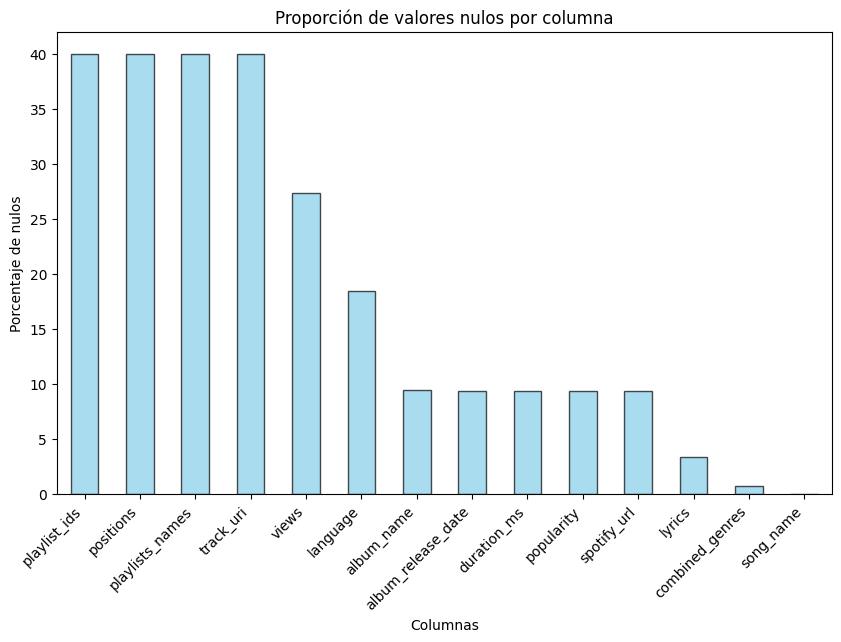

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns


# Crear un gráfico de barras para proporciones de nulos
missing_data = df.isnull().mean() * 100  # Proporción de nulos por columna
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)  # Filtrar columnas con nulos

plt.figure(figsize=(10, 6))
missing_data.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Proporción de valores nulos por columna")
plt.ylabel("Porcentaje de nulos")
plt.xlabel("Columnas")
plt.xticks(rotation=45, ha='right')
plt.show()

In [72]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126091 entries, 0 to 126090
Data columns (total 87 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   artist_name                         126091 non-null  object 
 1   song_name                           126090 non-null  object 
 2   recording_id                        126091 non-null  object 
 3   danceable                           126091 non-null  float64
 4   not_danceable                       126091 non-null  float64
 5   male                                126091 non-null  float64
 6   female                              126091 non-null  float64
 7   timbre_bright                       126091 non-null  float64
 8   timbre_dark                         126091 non-null  float64
 9   tonal                               126091 non-null  float64
 10  atonal                              126091 non-null  float64
 11  instrumental              

In [73]:
# Función para contar palabras clave en una columna de listas o strings
def count_keywords(column):
    all_words = []
    for value in column.dropna():
        if isinstance(value, list):
            all_words.extend(value)
        elif isinstance(value, str):
            all_words.extend(value.split())
    return Counter(all_words)

# Contar palabras clave
combined_genres_counter = count_keywords(d_clean['combined_genres'])

# Obtener las 15 palabras más frecuentes
combined_genres_top = combined_genres_counter.most_common(15)

# Crear gráficos
plt.figure(figsize=(12, 6))


# Gráfico para 'combined_genres'
plt.subplot(1, 2, 2)
plt.barh([x[0] for x in combined_genres_top], [x[1] for x in combined_genres_top], alpha=0.7, color='green')
plt.title('Palabras más frecuentes en combined_genres')
plt.xlabel('Frecuencia')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# Paso 2: Proporción de valores nulos
nulls = {
    
    "combined_genres": df['combined_genres'].isnull().mean()
}

# Gráfico de proporción de valores nulos
plt.figure(figsize=(8, 6))
plt.bar(nulls.keys(), nulls.values(), color=['blue', 'green'], alpha=0.7)
plt.title("Proporción de valores nulos")
plt.ylabel("Proporción")
plt.show()

# Paso 3: Comparación del número de etiquetas por fila
combined_genres_counts = df['combined_genres'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Gráfico de comparación de etiquetas por fila
plt.figure(figsize=(8, 6))
plt.hist(combined_genres_counts, bins=20, alpha=0.7, label='combined_genres', color='green')
plt.title('Distribución del número de etiquetas por fila')
plt.xlabel('Número de etiquetas')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


NameError: name 'd_clean' is not defined

### 'album_name', 'popularity', 'album_release_date', 'spotify_url'

In [6]:
import pandas as pd

file_path = r"C:\Users\solan\Downloads\get_data_from_songs\data\final_url.csv"
df_clean = pd.read_csv(file_path, low_memory=False)

In [7]:
# Crear un nuevo dataframe con las columnas de interés
columns_to_check = ['album_name', 'popularity', 'album_release_date', 'spotify_url']
df_no_url = df_clean[columns_to_check]

# Contar nulos en cada columna
null_counts = df_no_url.isnull().sum()

# Mostrar resultados
print("Número de nulos por columna:")
print(null_counts)

# Verificar si todas las columnas tienen el mismo número de nulos
same_nulls = null_counts.nunique() == 1
print(f"\n¿Tienen todas las columnas el mismo número de nulos? {'Sí' if same_nulls else 'No'}")
print(f"\nParece igualmente que es caso de urls no encontradas, voy a pasarlas de nuevo a buscar urls por si hubiera suerte")


Número de nulos por columna:
album_name            6191
popularity            6172
album_release_date    6172
spotify_url           6171
dtype: int64

¿Tienen todas las columnas el mismo número de nulos? No

Parece igualmente que es caso de urls no encontradas, voy a pasarlas de nuevo a buscar urls por si hubiera suerte


In [5]:
# Crear un dataframe con filas que tienen valores nulos en 'spotify_url'
df_no_url = df[df['spotify_url'].isnull()]

# Verificar las primeras filas del nuevo dataframe
print(df_no_url.head())

# Guardar el nuevo dataframe como un archivo CSV
df_no_url.to_csv('df_no_url.csv', index=False)
print("El archivo `df_no_url.csv` ha sido guardado exitosamente.")


         artist_name              song_name  \
30      kina grannis               together   
53   maximum balloon             the lesson   
59       i am arrows                    nun   
92    kill the noise    perfect combination   
108        los lobos  the lady and the rose   

                             recording_id  danceable  not_danceable   male  \
30   02352d4b-c907-4724-b515-c9c8a0849200      0.164          0.836  0.999   
53   037d34c3-b68d-4649-ad93-41f7dea68d13      0.934          0.066  0.653   
59   03c73e10-435b-4770-b7ca-93dc78ffc24b      0.991          0.009  0.974   
92   0665c0ec-3dfe-4312-845f-bd863cd03080      1.000          0.000  0.990   
108  075e85aa-979a-4280-ae69-6eb66c2603e8      0.930          0.070  0.029   

     female  timbre_bright  timbre_dark  tonal  ...  duration_ms  popularity  \
30    0.001          0.848        0.152  0.051  ...          NaN         NaN   
53    0.347          0.228        0.772  0.069  ...          NaN         NaN   
59    0.

Duplicados

In [1]:
# Paso 1: Contar duplicados por columna
duplicate_counts = df.apply(lambda col: col.duplicated().sum())

# Mostrar el número de duplicados por columna
print("Número de duplicados por columna:")
print(duplicate_counts)



NameError: name 'df' is not defined